# 4. SHAP ile Açıklanabilirlik — MaintiFlow
Her tahmin için hangi sensör değerlerinin riski tetiklediğini çıkarıyoruz (Detay Ekranı'nda kullanıcıya gösterilecek gerekçe).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed.csv')

artifact = joblib.load('../models/model.pkl')
clf = artifact['model']
feature_columns = artifact['feature_columns']
THRESHOLD = artifact['threshold']
print('Model yuklendi. Ozellikler:', feature_columns)

Model yuklendi. Ozellikler: ['Air temperature [K]', 'Process temperature [K]', 'temp_diff', 'Rotational speed [rpm]', 'Torque [Nm]', 'power_w', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']


## 4.1 Aynı train/test bölmesini yeniden üretme
03 notebook'undaki ile birebir aynı `random_state` ve `stratify` kullanarak aynı test setini elde ediyoruz.

In [2]:
feature_num = ['Air temperature [K]', 'Process temperature [K]', 'temp_diff',
               'Rotational speed [rpm]', 'Torque [Nm]', 'power_w', 'Tool wear [min]']
type_dummies = pd.get_dummies(df['Type'], prefix='Type')
X = pd.concat([df[feature_num], type_dummies], axis=1)[feature_columns]
y = df['failure_type']

X_train, X_test, y_train, y_test, mf_train, mf_test = train_test_split(
    X, y, df['Machine failure'],
    test_size=0.2, random_state=42, stratify=y
)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
mf_test = mf_test.reset_index(drop=True)
X_test.shape

(2000, 10)

## 4.2 SHAP TreeExplainer ile değerleri hesaplama

In [3]:
explainer = shap.TreeExplainer(clf)
shap_exp = explainer(X_test)
print('Shap values sekli:', shap_exp.values.shape)
print('Siniflar:', list(clf.classes_))

Shap values sekli: (2000, 10, 5)
Siniflar: ['HDF', 'NoFailure', 'OSF', 'PWF', 'TWF']


## 4.3 Genel özellik önemi (SHAP summary — NoFailure sınıfı üzerinden)
Bir özelliğin NoFailure olasılığını ne kadar aşağı çektiği = o özelliğin riski ne kadar yükselttiği.

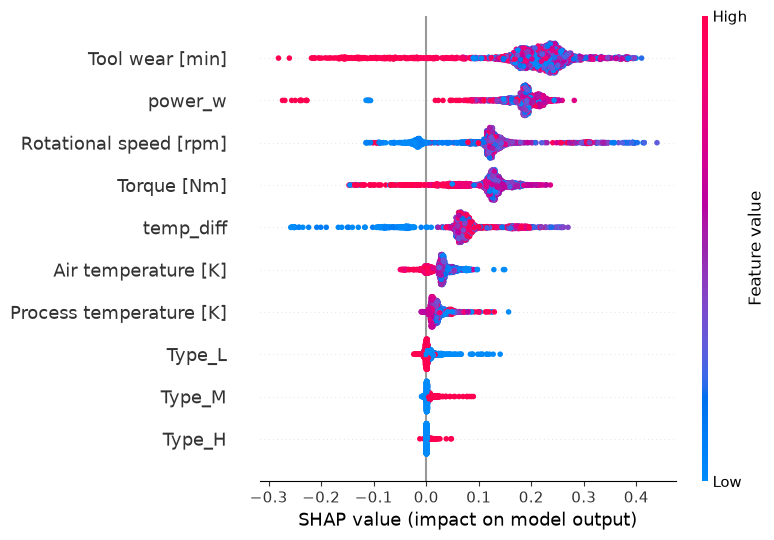

In [4]:
nofailure_idx = list(clf.classes_).index('NoFailure')
shap_nofailure = shap_exp[:, :, nofailure_idx]

fig = plt.figure(figsize=(7,5))
shap.summary_plot(shap_nofailure.values, X_test, show=False)
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

## 4.4 Tek bir tahmin için gerekçe çıkarma (ilk 3 sensör)
Her satır için: NoFailure olasılığını en çok **düşüren** (yani riski en çok **artıran**) ilk 3 özelliği buluyoruz. Bu, Detay Ekranı'nda "tahmin gerekçesi" olarak gösterilecek.

In [5]:
def get_top3_reasons(row_idx, shap_values_nofailure, X_data, feature_cols, top_n=3):
    vals = shap_values_nofailure[row_idx]
    order = np.argsort(vals)  # en negatif (riski en cok artiran) once
    top_idx = order[:top_n]
    reasons = []
    for i in top_idx:
        reasons.append({
            'feature': feature_cols[i],
            'value': float(X_data.iloc[row_idx][feature_cols[i]]),
            'shap_contribution': float(vals[i])
        })
    return reasons

proba_all = clf.predict_proba(X_test)
risk_all = 1 - proba_all[:, nofailure_idx]
pred_all = clf.predict(X_test)

flagged_idx = np.where(risk_all >= THRESHOLD)[0][:5]
for idx in flagged_idx:
    print(f'--- Satir {idx} | Risk: {risk_all[idx]:.2f} | Tahmin: {pred_all[idx]} | Gercek: {y_test[idx]} ---')
    for r in get_top3_reasons(idx, shap_nofailure.values, X_test, feature_columns):
        print(f"   {r['feature']} = {r['value']:.2f}  (SHAP katkisi: {r['shap_contribution']:.4f})")
    print()

--- Satir 28 | Risk: 0.95 | Tahmin: HDF | Gercek: HDF ---
   temp_diff = 8.00  (SHAP katkisi: -0.2556)
   Rotational speed [rpm] = 1363.00  (SHAP katkisi: -0.1129)
   Air temperature [K] = 303.20  (SHAP katkisi: -0.0437)

--- Satir 39 | Risk: 0.74 | Tahmin: HDF | Gercek: NoFailure ---
   temp_diff = 8.60  (SHAP katkisi: -0.1475)
   Rotational speed [rpm] = 1329.00  (SHAP katkisi: -0.0589)
   Air temperature [K] = 302.40  (SHAP katkisi: -0.0183)

--- Satir 79 | Risk: 0.94 | Tahmin: PWF | Gercek: PWF ---
   power_w = 9137.76  (SHAP katkisi: -0.2562)
   Torque [Nm] = 63.60  (SHAP katkisi: -0.1191)
   Rotational speed [rpm] = 1372.00  (SHAP katkisi: -0.0209)

--- Satir 127 | Risk: 0.97 | Tahmin: HDF | Gercek: HDF ---
   temp_diff = 7.90  (SHAP katkisi: -0.2565)
   Rotational speed [rpm] = 1349.00  (SHAP katkisi: -0.0894)
   Air temperature [K] = 302.70  (SHAP katkisi: -0.0494)

--- Satir 152 | Risk: 0.95 | Tahmin: PWF | Gercek: PWF ---
   power_w = 9502.06  (SHAP katkisi: -0.2737)
   Torqu

## 4.5 Doğru ve yanlış alarm örneklerini karşılaştırma
Modelin gerçekten haklı gerekçelerle mi yoksa rastgele mi alarm verdiğini anlamak için bir doğru pozitif ve bir yanlış pozitif örneği yan yana inceliyoruz.

In [6]:
true_positive_idx = np.where((risk_all >= THRESHOLD) & (mf_test == 1))[0]
false_positive_idx = np.where((risk_all >= THRESHOLD) & (mf_test == 0))[0]

print('Dogru pozitif ornek sayisi:', len(true_positive_idx))
print('Yanlis pozitif ornek sayisi:', len(false_positive_idx))

if len(true_positive_idx) > 0:
    i = true_positive_idx[0]
    print(f'\n[DOGRU POZITIF] Satir {i} | Risk: {risk_all[i]:.2f} | Tahmin: {pred_all[i]} | Gercek arizali, tip={y_test[i]}')
    for r in get_top3_reasons(i, shap_nofailure.values, X_test, feature_columns):
        print(f"   {r['feature']} = {r['value']:.2f}  (SHAP: {r['shap_contribution']:.4f})")

if len(false_positive_idx) > 0:
    i = false_positive_idx[0]
    print(f'\n[YANLIS POZITIF] Satir {i} | Risk: {risk_all[i]:.2f} | Tahmin: {pred_all[i]} | Gercekte saglam')
    for r in get_top3_reasons(i, shap_nofailure.values, X_test, feature_columns):
        print(f"   {r['feature']} = {r['value']:.2f}  (SHAP: {r['shap_contribution']:.4f})")

Dogru pozitif ornek sayisi: 54
Yanlis pozitif ornek sayisi: 12

[DOGRU POZITIF] Satir 28 | Risk: 0.95 | Tahmin: HDF | Gercek arizali, tip=HDF
   temp_diff = 8.00  (SHAP: -0.2556)
   Rotational speed [rpm] = 1363.00  (SHAP: -0.1129)
   Air temperature [K] = 303.20  (SHAP: -0.0437)

[YANLIS POZITIF] Satir 39 | Risk: 0.74 | Tahmin: HDF | Gercekte saglam
   temp_diff = 8.60  (SHAP: -0.1475)
   Rotational speed [rpm] = 1329.00  (SHAP: -0.0589)
   Air temperature [K] = 302.40  (SHAP: -0.0183)
